# RealLift Demonstration: DoE - Design of Experiments

## 1. Installation

In [ ]:
# From GitHub
# %pip install git+https://github.com/RobertoJuniorWXYZ/RealLift.git
# or
# From PyPI
%pip install reallift

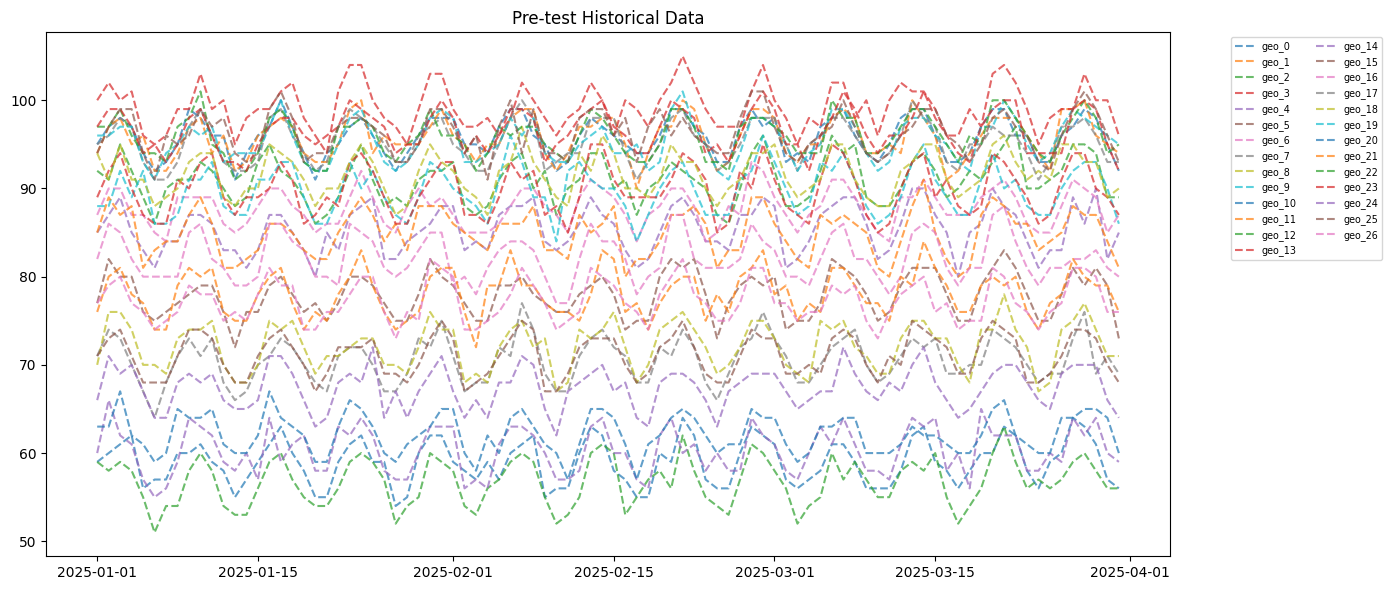

In [3]:
from reallift import generate_geo_data

file_pre_test = 'demo_geodata_pre_test.csv'
start_date = "2025-01-01"
end_date = "2025-03-31"

geo_data = generate_geo_data(
    start_date = start_date,
    end_date = end_date,
    n_geos=27,
    pre_only=True,
    trend_slope=0.01,
    seasonality_amplitude=3,
    seasonality_period=7,
    noise_std=[1, 1.5],
    base_value=[50, 100],
    random_seed=42,
    save_csv=True,
    pre_file_name=file_pre_test,
    as_integer=True,
)

In [4]:
from reallift import design_of_experiments

file_pre_test = 'demo_geodata_pre_test.csv'
start_date = "2025-01-01"
end_date = "2025-03-31"

doe = design_of_experiments(
    filepath=file_pre_test,
    date_col="date",
    start_date=start_date,
    end_date=end_date,
    geos=None,
    pct_treatment=None,
    fixed_treatment=None,
    mde=None,
    experiment_days=[21, 60],
    n_folds=5,
    search_mode="ranking",
    verbose=True
)




======================= DESIGN OF EXPERIMENTS ========================

Total geos available: 27
Scenarios to evaluate: 3
Search mode: ranking
Pre-treatment period: 2025-01-01 → 2025-03-31
Experiment duration: [21, 60]

Screening all geos individually...


Screening geos:   0%|          | 0/27 [00:00<?, ?it/s]

Screening geos: 100%|██████████| 27/27 [00:01<00:00, 17.80it/s]


Global ranking (top 8): ['geo_17', 'geo_0', 'geo_19', 'geo_23', 'geo_15', 'geo_22', 'geo_6', 'geo_26']

----------------------------------------------------------------------
SCENARIO 1 — 10% Treatment (3 geos)
----------------------------------------------------------------------

  Cluster | Treatment  | #Ctrl | σ        | R²     | MDE @21d  | MDE @30d  | MDE @60d 
  --------------------------------------------------------------------------------
  0       | geo_17     | 10    | 0.0124   | 0.7366 | 0.76%     | 0.64%     | 0.45%    
  1       | geo_0      | 10    | 0.0129   | 0.6853 | 0.79%     | 0.66%     | 0.47%    
  2       | geo_19     | 9     | 0.0142   | 0.6620 | 0.87%     | 0.73%     | 0.51%    
  --------------------------------------------------------------------------------
  CONSOL. | pooled     |       | 0.0084   |        | 0.51%     | 0.43%     | 0.30%    

  EXPERIMENTAL SCOPE
  Distinct Geos Used   : 21 (78% coverage)

  TEST POOL (TREATMENT UNITS): geo_0, geo_17, geo_

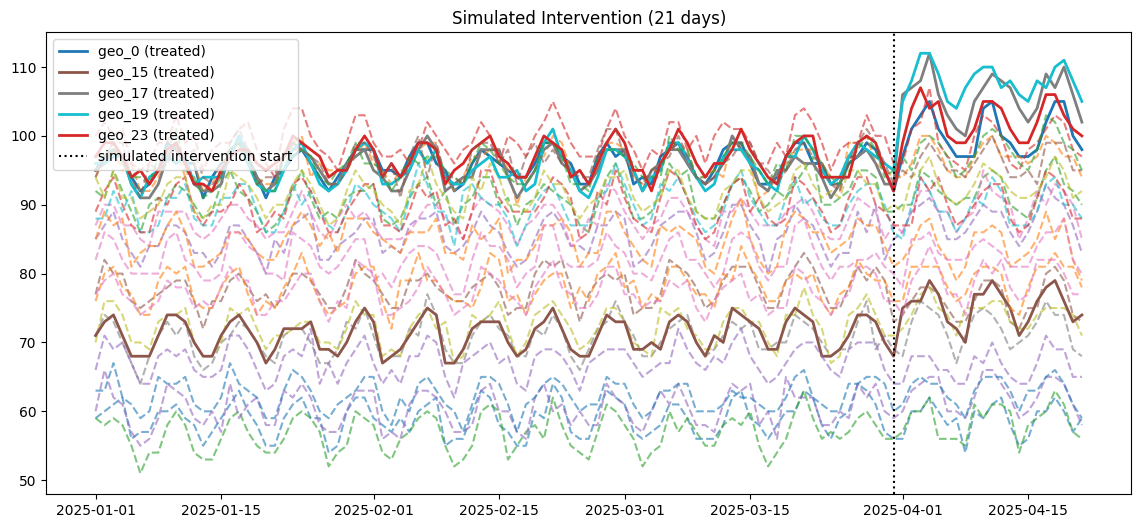

In [9]:
from reallift import generate_simulated_intervention

file_post_test = 'demo_geodata_post_test.csv'

geo_data_intervention = generate_simulated_intervention(
    filepath=file_pre_test,
    days=21,
    treatment_geos=["geo_0", "geo_15", "geo_17", "geo_19", "geo_23"],
    lift=[0.05, 0.10],
    trend_slope=0.01,
    seasonality_amplitude=3,
    seasonality_period=7,
    noise_std=[1, 1.5],
    random_seed=42,
    save_csv=True,
    as_integer=True,
    file_name=file_post_test
)


In [6]:
from reallift import run_geo_experiment

results = run_geo_experiment(
    filepath=file_post_test,
    date_col="date",
    treatment_start_date="2025-04-01",
    treatment_end_date="2025-04-22",
    doe=doe, 
    scenario=1,
    plot=False
)



>>> Using experiment design from DoE Scenario 1

--------------------------------------------------
-------------- ANALYZING CLUSTER 0 ---------------
--------------------------------------------------
Treatment: ['geo_17']
Control: ['geo_1', 'geo_3', 'geo_4', 'geo_9', 'geo_11', 'geo_12', 'geo_14', 'geo_16', 'geo_18', 'geo_22', 'geo_24']


=== GEO SYNTHETIC CONTROL (Cluster 0) ===

Weights:
geo_1: 0.3148
geo_3: 0.0954
geo_4: 0.0919
geo_9: 0.0695
geo_11: 0.0142
geo_12: 0.0014
geo_14: 0.0591
geo_16: 0.0387
geo_18: 0.1335
geo_22: 0.1370
geo_24: 0.0446

Treatment period:
Start: 2025-04-01
End: 2025-04-21
Duration: 21 days

Mean lift (abs): 9.25
Mean lift (%): 9.57 %
Total lift: 194.21

=== SIGNIFICANCE (Cluster 0) ===

T-Test:
t-stat: 24.419
p-value: 0.0000

=== BOOTSTRAP TESTS SUMMARY (Cluster 0) ===
Total lift (abs): 194.21
95% CI (abs): [179.00, 209.31]
Total lift (%): 9.57%
95% CI (%): [8.85%, 10.34%]
p-value (bootstrap): 0.0000
✔ Lift statistically significant (CI does not cross 0)

